In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("ab_test_data.csv")
print(df.head())

                                user_id                   timestamp  \
0  7f6833e6-1141-4f20-b4b2-f1e31019b1fd  2023-07-04 04:40:55.848109   
1  e6a6e960-d3f3-4074-a516-ba1e609b211e  2023-07-06 00:26:45.486187   
2  4d3fbfa5-6847-410a-bac2-477f01d5f400  2023-07-10 20:24:33.639464   
3  361457d9-a044-48f7-981c-d67dc3861679  2023-07-20 07:04:49.957013   
4  285cd63d-7d03-427f-a062-1fa2dd2e77d6  2023-07-19 23:27:50.116680   

  test_group  conversion  
0          a           0  
1          b           0  
2          b           0  
3          b           0  
4          b           0  


In [3]:
print("\nІнформація про DataFrame:")
df.info()


Інформація про DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     19998 non-null  object
 1   timestamp   19998 non-null  object
 2   test_group  19998 non-null  object
 3   conversion  19998 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 625.1+ KB


In [4]:
print("\nРозмір таблиці:", df.shape)


Розмір таблиці: (19998, 4)


In [5]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

Кількість користувачів в групах A та B відповідно.

In [6]:
users_by_group = df['test_group'].value_counts()
print("Кількість користувачів:")
print(users_by_group)

Кількість користувачів:
test_group
a    10013
b     9985
Name: count, dtype: int64


Кількість конверсій в групах A та B відповідно.


In [7]:
conversions_by_group = df.groupby('test_group')['conversion'].sum()
print("\nКількість конверсій:")
print(conversions_by_group)


Кількість конверсій:
test_group
a    611
b    889
Name: conversion, dtype: int64


Рівень конверсії в групах A та B відповідно.

In [8]:
conversion_rate = df.groupby('test_group')['conversion'].mean()
conversion_rate = (conversion_rate * 100).round(2)
print("\nКонверсія (%):")
print(conversion_rate)


Конверсія (%):
test_group
a    6.1
b    8.9
Name: conversion, dtype: float64


Дату початку та дату кінця тесту, а також тривалість тесту в днях.

In [9]:
start_date = df['timestamp'].min()
end_date = df['timestamp'].max()
duration = (end_date - start_date).days
print("\nДата початку:", start_date)
print("Дата кінця:", end_date)
print("Тривалість тесту (днів):", duration)


Дата початку: 2023-07-03 01:42:34.033708
Дата кінця: 2023-07-25 01:41:19.152664
Тривалість тесту (днів): 21


Z-тест для порівняння двох пропорцій

In [10]:
from statsmodels.stats.proportion import proportions_ztest
success = [611, 889]
nobs = [10013, 9985]
stat, p_value = proportions_ztest(success, nobs)
print("Z-статистика:", round(stat, 4))
print("p-value:", p_value)

Z-статистика: -7.5197
p-value: 5.491217728445103e-14


Отримане p-value < 0.05, тому нульову гіпотезу відхиляємо.
Різниця між групами є статистично значущою.
Варіант B (знижка 50%) показав вищу конверсію та є кращим.

Візуалізація для порівняння середніх значень у групах з 95% довірчими інтервалами

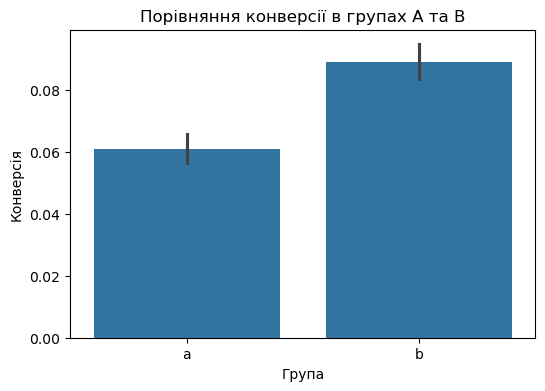

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
# строим график
plt.figure(figsize=(6,4))
sns.barplot(
    data=df,
    x='test_group',
    y='conversion',
    errorbar=('ci', 95)
)
plt.title('Порівняння конверсії в групах A та B')
plt.xlabel('Група')
plt.ylabel('Конверсія')
plt.show()

Група B має вищу середню конверсію порівняно з групою A.
95% довірчі інтервали майже не перекриваються, що підтверджує статистичну значущість різниці.

Висновки A/B тесту
У рамках A/B тесту порівнювалися два варіанти екрану підписки:
група A - стандартна пропозиція, група B - пропозиція зі знижкою 50%.

За результатами аналізу:

-- конверсія в групі A склала 6.1%, у групі B - 8.9%

-- різниця між групами є статистично значущою (p-value < 0.05)

-- довірчі інтерали майже не перекриваються

Це свідчить про те, що варіант B значно покращує конверсію.

Рекомендується впровадити варіант B, оскільки він демонструє вищу ефективність та статистично значуще покращення ключової метрики.

Побудуй графік, що відображатиме зміну конверсії в часі. І не забувай врахувати, що на цей раз в нас дійсно є дані про час здійснення івенту.

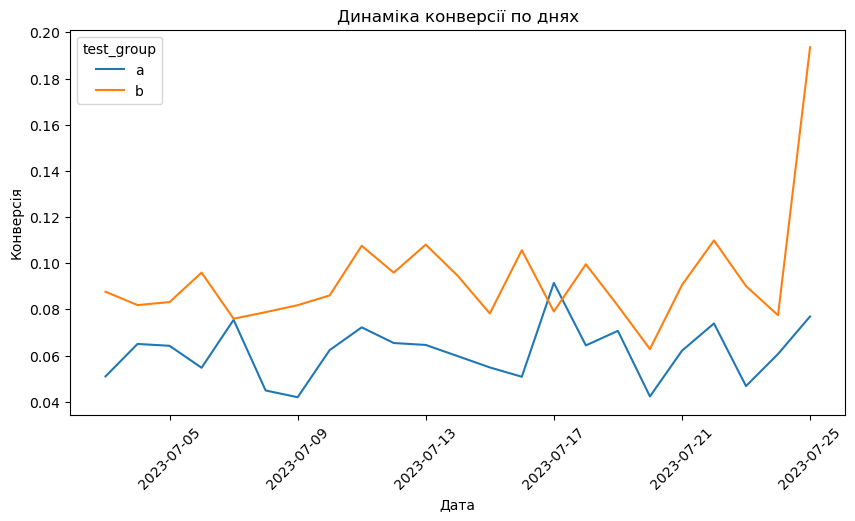

In [12]:
# создаём колонку с датой (без времени)
df['date'] = df['timestamp'].dt.date

# считаем конверсию по дням и группам
daily_conversion = df.groupby(['date', 'test_group'])['conversion'].mean().reset_index()

# строим график
plt.figure(figsize=(10,5))

sns.lineplot(
    data=daily_conversion,
    x='date',
    y='conversion',
    hue='test_group'
)

plt.title('Динаміка конверсії по днях')
plt.xlabel('Дата')
plt.ylabel('Конверсія')
plt.xticks(rotation=45)

plt.show()